In [2]:
import numpy as np
import pandas as pd
#from sympy import *
#from sympy.plotting import plot3d
#from sympy.solvers.inequalities import solve_univariate_inequality
import matplotlib.pyplot as plt
from numpy.linalg import inv

In [4]:
#init_printing(use_unicode=False,wrap_line=False, no_global=True)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

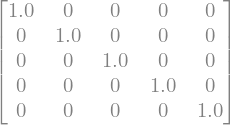

In [5]:
E = Matrix (np.eye(5))
E

In [6]:
y = Matrix ([1,2,3,4,5])
y

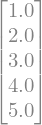

In [7]:
E*y

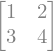

In [8]:
A = Matrix ([[1,2], [3,4]])
A

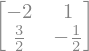

In [9]:
R = A**-1
R

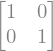

In [10]:
A*R

In [13]:
y = Matrix ([5,6])
y

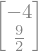

In [14]:
R*y

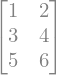

In [11]:
B = Matrix ([[1,2], [3,4], [5,6]])
B

In [12]:
R = B**-1
R

NonSquareMatrixError: 

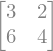

In [15]:
B = Matrix ([[3,2], [6,4]])
B

In [16]:
B.det()

In [17]:
A.det()

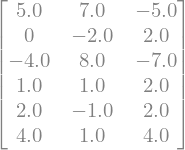

In [18]:
X = Matrix([[5.0,7.0,-5.0],
            [0.0,-2.0,2.0],
            [-4.0,8.0,-7.0],
            [1.0,1.0,2.0],
            [2.0,-1.0,2.0],
            [4.0,1.0,4.0]])
X

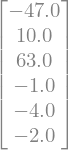

In [27]:
y = Matrix([-47.0,10.0,63.0,-1.0,-4.0,-2.0])
y

In [23]:
(X.T*X).det()

In [24]:
X_pseudo_inverse = (X.T*X)**(-1)*X.T

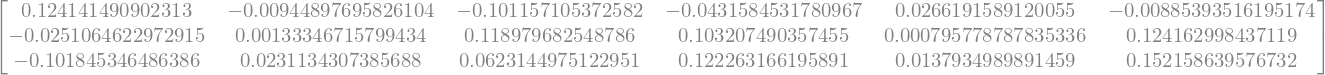

In [25]:
X_pseudo_inverse

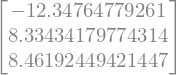

In [28]:
w = X_pseudo_inverse*y
w

In [53]:
S = np.array([50,60,70,100])
S

array([ 50,  60,  70, 100])

In [31]:
price = np.array ([10,30,40,50])
price

array([10, 30, 40, 50])

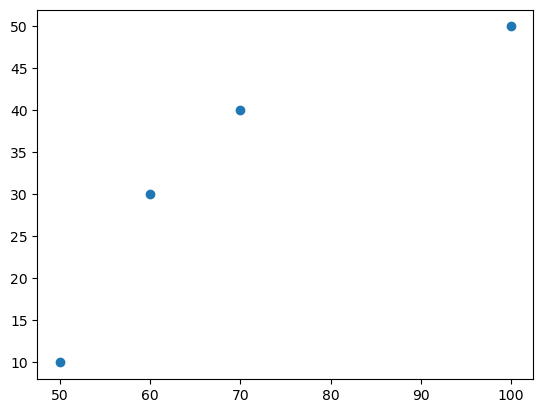

In [32]:
plt.scatter(S,price);

In [33]:
X = np.array([[1,50],[1,60],[1,70],[1,100]])
X

array([[  1,  50],
       [  1,  60],
       [  1,  70],
       [  1, 100]])

In [34]:
#1.Транспонируем матрицу
X.T

array([[  1,   1,   1,   1],
       [ 50,  60,  70, 100]])

In [37]:
#2. Перемножаем матрицу транспонированную на себя саму
X_dot = X.T.dot(X)
X_dot

array([[    4,   280],
       [  280, 21000]])

In [40]:
#3.Находим обратную матрицу
X_inverted = inv(X_dot)
X_inverted

array([[ 3.75000000e+00, -5.00000000e-02],
       [-5.00000000e-02,  7.14285714e-04]])

In [41]:
#4. Находим коэффициенты регрессии
w = X_inverted.dot(X.T).dot(price)
w

array([-17.5       ,   0.71428571])

In [43]:
inv((X.T).dot(X)).dot(X.T).dot(price)

array([-17.5       ,   0.71428571])

In [44]:
w

array([-17.5       ,   0.71428571])

In [56]:
price

array([10, 30, 40, 50])

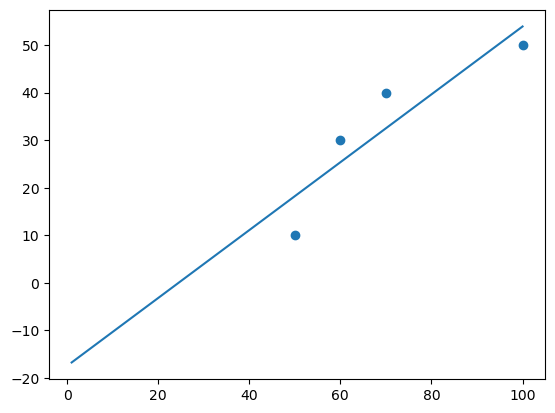

In [54]:
x_range = np.linspace(X.min(),X.max())
model = w[0] + w[1]*x_range
plt.scatter(S,price)
plt.plot(x_range, model);

In [4]:
names = ['CRIM','ZN','INDUS','CHAS','NOX','RM',
        'AGE','DIS','RAD','TAX', 'PTRATTO','B','LSTAT','MEDV']

In [5]:
pd.read_csv('housing.csv', sep = '\s+', names = names)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATTO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [7]:
df = pd.read_csv('housing.csv', delim_whitespace = True, names = names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATTO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
df.shape

(506, 14)

In [8]:
array = df.values

In [9]:
X = array[:,:13]
y = array[:,13]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [11]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [12]:
model.coef_

array([-1.13055924e-01,  3.01104641e-02,  4.03807204e-02,  2.78443820e+00,
       -1.72026334e+01,  4.43883520e+00, -6.29636221e-03, -1.44786537e+00,
        2.62429736e-01, -1.06467863e-02, -9.15456240e-01,  1.23513347e-02,
       -5.08571424e-01])

In [13]:
y_pred = model.predict(X_test)

In [15]:
S = np.array([50,60,70,100]).reshape(-1,1)
S             

array([[ 50],
       [ 60],
       [ 70],
       [100]])

In [17]:
price = np.array([10,30,40,50])

In [90]:
lr = LinearRegression()
lr.fit(S,price)

LinearRegression()

In [93]:
w = lr.coef_
w

array([0.71428571])

In [94]:
lr.predict(S)

array([18.21428571, 25.35714286, 32.5       , 53.92857143])

Метрики качества

In [16]:
mean_squared_error(y_pred,y_test)

24.29111947497344

In [17]:
np.sqrt(mean_squared_error(y_pred,y_test))

4.928602182665328

In [18]:
mean_absolute_error(y_pred,y_test)

3.1890919658878345

In [19]:
r2_score (y_pred, y_test)

0.6333247469014387

In [14]:
class Linear:
    def __init__(self,X,y):
        self.X = X
        self.y = y
        self.coef = None
        self.predicted = []
        self.error = None

    def fit(self):
        self.coef = inv((self.X.T).dot(self.X)).dot(self.X.T).dot(self.y)
    def predict(self):
        self.predicted = sum(self.coef.reshape(-1,1)*self.X.T)
    def rmse(self):
        self.error = np.sqrt(sum((self.y-self.predicted)**2)/len(self.y))

In [34]:
X = np.array([[1,50],[1,60],[1,70],[1,100]])
X

array([[  1,  50],
       [  1,  60],
       [  1,  70],
       [  1, 100]])

In [35]:
price

array([10, 30, 40, 50])

In [36]:
model = Linear (X,price)

In [37]:
model.X

array([[  1,  50],
       [  1,  60],
       [  1,  70],
       [  1, 100]])

In [38]:
model.fit()

In [39]:
model.coef

array([-17.5       ,   0.71428571])

In [40]:
model.predict()

In [41]:
model.predicted

array([18.21428571, 25.35714286, 32.5       , 53.92857143])

In [25]:
model.coef.reshape(-1,1)

array([[-17.5       ],
       [  0.71428571]])

In [42]:
model.rmse()
model.error

6.338656910463873

In [27]:
model.X.T

array([[  1,   1,   1,   1],
       [ 50,  60,  70, 100]])

In [43]:
X_new = np.array([50,60,70,100])
X_new

array([ 50,  60,  70, 100])

In [44]:
X_new = X_new.reshape(-1,1)
X_new

array([[ 50],
       [ 60],
       [ 70],
       [100]])

In [45]:
model = Linear (X_new,price)
model.fit()
model.coef

array([0.48095238])

In [46]:
model.predict()

In [47]:
model.predicted

array([24.04761905, 28.85714286, 33.66666667, 48.0952381 ])

In [48]:
model.rmse()
model.error

7.784294322238728

In [49]:
X = array[:,:13]
y = array [:,13]

In [50]:
model = Linear(X,y)
model.fit()

In [52]:
model.coef

array([-9.28965170e-02,  4.87149552e-02, -4.05997958e-03,  2.85399882e+00,
       -2.86843637e+00,  5.92814778e+00, -7.26933458e-03, -9.68514157e-01,
        1.71151128e-01, -9.39621540e-03, -3.92190926e-01,  1.49056102e-02,
       -4.16304471e-01])

In [53]:
model.predict()

In [54]:
model.rmse()
model.error

4.915902697381883

## Регуляризация

In [55]:
df = pd.read_csv('non_linear.csv')
df.head()

,x_train,y_train
0,0.138368,0.838812
1,0.157237,0.889313
2,0.188684,1.430040
3,0.685553,1.717309
4,0.874237,2.032588


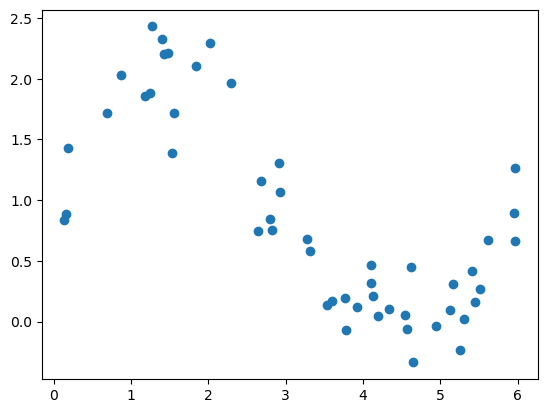

In [56]:
plt.scatter(df.x_train, df.y_train);

In [81]:
df.shape

(50, 2)

In [70]:
X = df.x_train.values
y = df.y_train.values

In [71]:
X = X.reshape(-1,1)

In [72]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size = 0.2, random_state = 10)

In [73]:
model = Ridge().fit(X_train,y_train)

In [66]:
y_pred = model.predict(X_valid)

In [74]:
mean_squared_error(y_valid, y_pred)

0.2694249787201976

In [75]:
model = Ridge(alpha=0.5).fit(X_train,y_train)
y_pred = model.predict(X_valid)
mean_squared_error(y_valid, y_pred)

0.2688444076033385

In [76]:
model = Ridge(alpha=1).fit(X_train,y_train)
y_pred = model.predict(X_valid)
mean_squared_error(y_valid, y_pred)

0.2694249787201976

In [77]:
model = Lasso().fit(X_train,y_train)
y_pred = model.predict(X_valid)
mean_squared_error(y_valid, y_pred)

0.743631365008917

In [78]:
model = Lasso(alpha=0.5).fit(X_train,y_train)
y_pred = model.predict(X_valid)
mean_squared_error(y_valid, y_pred)

0.44205423523619514

In [79]:
model = ElasticNet(alpha=0.5).fit(X_train,y_train)
y_pred = model.predict(X_valid)
mean_squared_error(y_valid, y_pred)

0.34925889376938374

In [87]:
model = LinearRegression().fit(X_train,y_train)
y_pred = model.predict(X_valid)
mean_squared_error(y_valid, y_pred)

0.2682718649158076

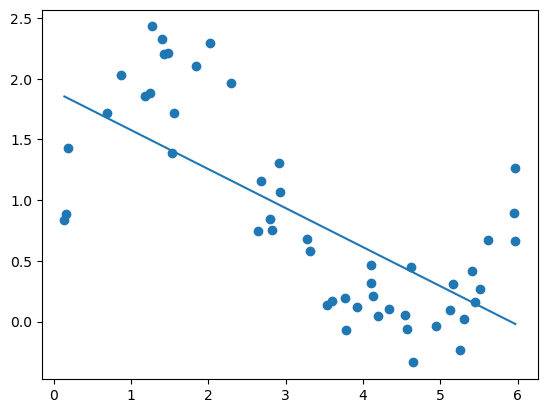

In [88]:
x_linspace = np.linspace(df['x_train'].min(),df['x_train'].max(), num = 100)
y_linspace =  model.predict (x_linspace.reshape(-1,1))
plt.plot(x_linspace,y_linspace)
plt.scatter(df.x_train,df.y_train);

In [83]:
model = SGDRegressor(learning_rate = 'constant', eta0=0.01, fit_intercept = True, random_state = 42)

In [84]:
model.fit(X_train, y_train)

SGDRegressor(learning_rate='constant', random_state=42)

In [85]:
mean_squared_error(y_valid, model.predict(X_valid))

0.35026072372430317

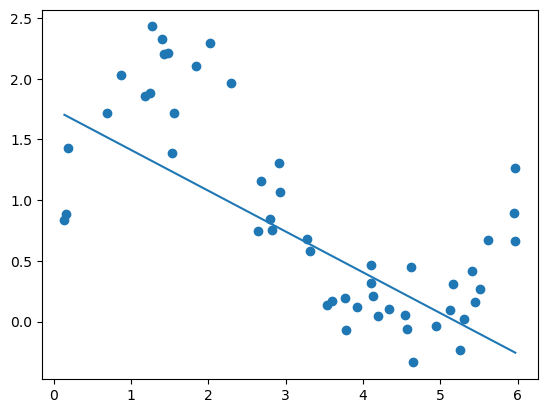

In [86]:
x_linspace = np.linspace(df['x_train'].min(),df['x_train'].max(), num = 100)
y_linspace =  model.predict (x_linspace.reshape(-1,1))
plt.plot(x_linspace,y_linspace)
plt.scatter(df.x_train,df.y_train);